In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv('loanapproval.csv')

In [5]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   applicant_id          1000 non-null   int64 
 1   age                   1000 non-null   int64 
 2   gender                1000 non-null   object
 3   marital_status        1000 non-null   object
 4   annual_income         1000 non-null   int64 
 5   loan_amount           1000 non-null   int64 
 6   credit_score          1000 non-null   int64 
 7   num_dependents        1000 non-null   int64 
 8   existing_loans_count  1000 non-null   int64 
 9   employment_status     1000 non-null   object
 10  loan_approved         1000 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 86.1+ KB


In [6]:
df = df.drop('applicant_id', axis=1)

In [8]:
# Converting categorical columns to numbers

In [7]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,loan_approved,gender_Male,marital_status_Married,marital_status_Single,employment_status_Self-employed,employment_status_Unemployed
0,59,100073,7169,793,1,1,1,True,False,False,False,True
1,49,112197,23556,789,0,2,1,True,True,False,False,False
2,35,84429,27052,372,1,4,0,True,False,False,False,True
3,63,124195,11313,808,3,4,1,False,False,True,True,False
4,28,81627,13315,689,0,1,1,False,True,False,False,True


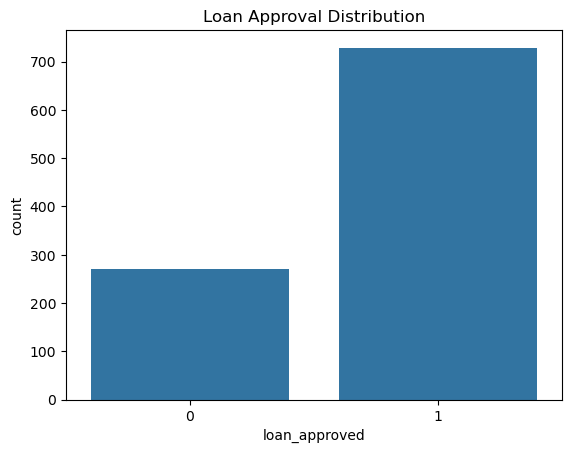

In [9]:
# Step 4: Quick EDA 
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='loan_approved', data=df)
plt.title("Loan Approval Distribution")
plt.show()

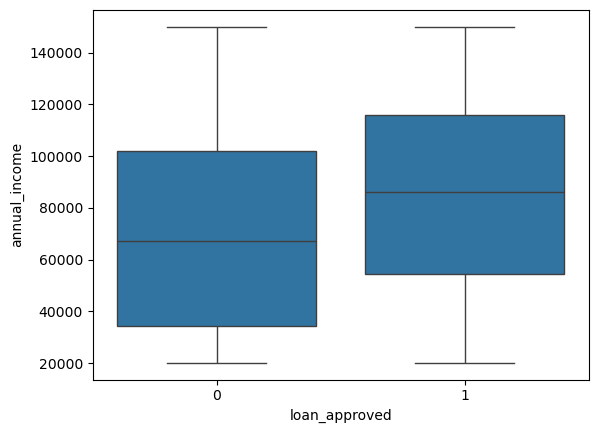

In [10]:
sns.boxplot(x='loan_approved', y='annual_income', data=df)
plt.show()

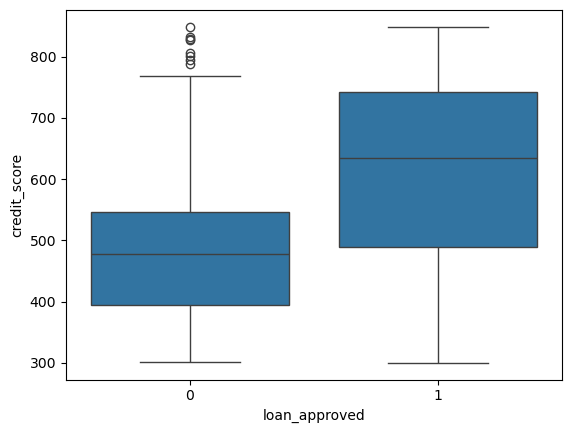

In [11]:
sns.boxplot(x='loan_approved', y='credit_score', data=df)
plt.show()

In [12]:
# Step 5: Prepare Data for Modeling
from sklearn.model_selection import train_test_split

X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# Step 6: Build Your First Model
# Logistic regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

c:\Users\georg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
# Predictions
y_pred = model.predict(X_test)

In [15]:
# Step 7 Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.875
[[ 41  14]
 [ 11 134]]
              precision    recall  f1-score   support

           0       0.79      0.75      0.77        55
           1       0.91      0.92      0.91       145

    accuracy                           0.88       200
   macro avg       0.85      0.83      0.84       200
weighted avg       0.87      0.88      0.87       200



In [16]:
# Random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.98


In [18]:
# What We Are Checking

# We want to see: Is it good for BOTH: Approved loans & Rejected loans 
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[ 51   4]
 [  0 145]]
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        55
           1       0.97      1.00      0.99       145

    accuracy                           0.98       200
   macro avg       0.99      0.96      0.97       200
weighted avg       0.98      0.98      0.98       200



In [19]:
# Feature importance; What factors influence the loan approval mostly
import pandas as pd

feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False)

credit_score                       0.217047
num_dependents                     0.210404
existing_loans_count               0.180373
employment_status_Unemployed       0.126230
annual_income                      0.124957
loan_amount                        0.056751
age                                0.043976
employment_status_Self-employed    0.016850
gender_Male                        0.008967
marital_status_Single              0.007733
marital_status_Married             0.006712
dtype: float64

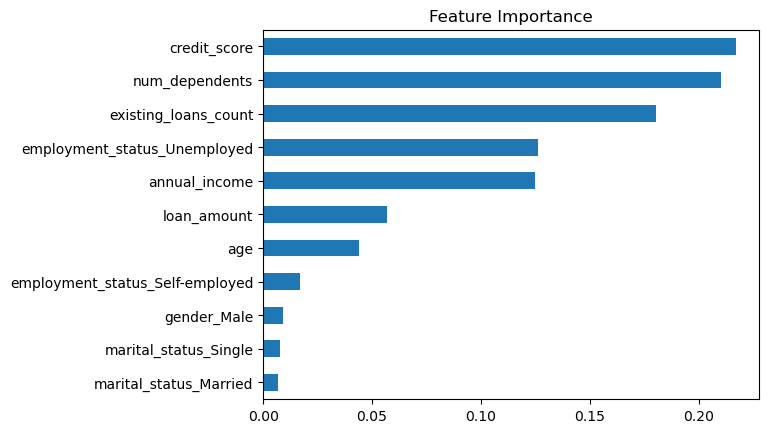

In [20]:
import matplotlib.pyplot as plt

feature_importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()